In [ ]:
"""
MNIST Digit Classifier
=======================
Trains a neural network (TensorFlow/Keras) to classify handwritten digits (0-9)
from the MNIST dataset.

Pipeline:
  1. Load MNIST and split into train / validation / test sets
  2. Preview some sample images
  3. Build and train a plain fully-connected (dense) neural network
  4. Plot training vs. validation loss
  5. Evaluate on the held-out test set: confusion matrix, precision, recall,
     F1-score, and accuracy

Run:
    python mnist_digit_classifier.py
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)



In [ ]:

# ---------------------------------------------------------------------------
# 1. Load data and split into train / validation / test
# ---------------------------------------------------------------------------
def load_and_split_data(val_fraction=0.1):
    """Loads MNIST and splits it into train, validation, and test sets.

    Keras' MNIST loader already gives us a 60,000 / 10,000 train/test split.
    We carve out `val_fraction` of the training set to use for validation.
    """
    (x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

    x_train, x_val, y_train, y_val = train_test_split(
        x_train_full,
        y_train_full,
        test_size=val_fraction,
        random_state=RANDOM_SEED,
        stratify=y_train_full,
    )

    print(f"Train set:      {x_train.shape[0]:>6} images")
    print(f"Validation set: {x_val.shape[0]:>6} images")
    print(f"Test set:       {x_test.shape[0]:>6} images")

    return (x_train, y_train), (x_val, y_val), (x_test, y_test)




In [ ]:
# ---------------------------------------------------------------------------
# 2. Preview some sample images
# ---------------------------------------------------------------------------
def preview_samples(images, labels, n=10, title="Sample MNIST Images", save_path=None):
    """Displays a grid of `n` sample images with their labels.

    Saves the figure to `save_path` (if given) and also tries to display it
    interactively (works when run in an environment with a display).
    """
    n = min(n, len(images))
    cols = min(n, 5)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows))
    axes = np.array(axes).reshape(-1)

    idxs = np.random.choice(len(images), size=n, replace=False)
    for ax, idx in zip(axes, idxs):
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(f"Label: {labels[idx]}")
        ax.axis("off")

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved sample image preview to: {save_path}")

    try:
        plt.show()
    except Exception:
        pass  # No display available (e.g. headless environment) - that's fine.

    plt.close(fig)


def offer_interactive_preview(x_train, y_train):
    """Lets the user interactively choose how many sample images to view."""
    print("\nWould you like to preview some sample digit images? [y/n]: ", end="")
    choice = input().strip().lower()
    if choice.startswith("y"):
        print("How many images would you like to see? (default 10): ", end="")
        raw = input().strip()
        n = int(raw) if raw.isdigit() else 10
        preview_samples(x_train, y_train, n=n, save_path="sample_images.png")



In [ ]:

# ---------------------------------------------------------------------------
# 3. Preprocess
# ---------------------------------------------------------------------------
def preprocess(images):
    """Normalizes pixel values to [0, 1] and flattens each 28x28 image to a
    784-length vector (required for a fully-connected network)."""
    images = images.astype("float32") / 255.0
    images = images.reshape((images.shape[0], -1))  # (N, 28, 28) -> (N, 784)
    return images


In [49]:
# ---------------------------------------------------------------------------
# 4. Build the model
# ---------------------------------------------------------------------------
def build_model():
    #A plain, fully-connected nueral network 
    model = keras.Sequential(
        [
            keras.Input(shape=(784,)),
            keras.layers.Dense(256, activation="relu"),
            keras.layers.Dropout(0.3,),
            keras.layers.Dense(128, activation="relu"),
            keras.layers.Dropout(0.3,),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )



    #compile the model
    model.compile(
        optimizer="adam", 
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        )
    
    return model

In [50]:

# ---------------------------------------------------------------------------
# 5. Plot training / validation loss
# ---------------------------------------------------------------------------
def plot_loss(history, save_path="training_validation_loss.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs. Validation Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["accuracy"], label="Training Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training vs. Validation Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"Saved loss/accuracy curves to: {save_path}")

    try:
        plt.show()
    except Exception:
        pass

    plt.close(fig)



In [51]:

# ---------------------------------------------------------------------------
# 6. Evaluate: confusion matrix + precision/recall/F1/accuracy
# ---------------------------------------------------------------------------
def evaluate_model(model, x_test, y_test, save_path="confusion_matrix.png"):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print("\n========== Test Set Performance ==========")
    print(f"Accuracy:           {acc:.4f}")
    print(f"Precision (macro):  {precision:.4f}")
    print(f"Recall (macro):     {recall:.4f}")
    print(f"F1-score (macro):   {f1:.4f}")
    print("\nPer-class report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(ax=ax, cmap="Blues", colorbar=True)
    ax.set_title("Confusion Matrix - MNIST Test Set")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"\nSaved confusion matrix to: {save_path}")

    try:
        plt.show()
    except Exception:
        pass

    plt.close(fig)

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}



In [52]:

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

print("Loading MNIST dataset...")
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_and_split_data(val_fraction=0.1)



Loading MNIST dataset...
Train set:       54000 images
Validation set:   6000 images
Test set:        10000 images



Would you like to preview some sample digit images? [y/n]: How many images would you like to see? (default 10): Saved sample image preview to: sample_images.png


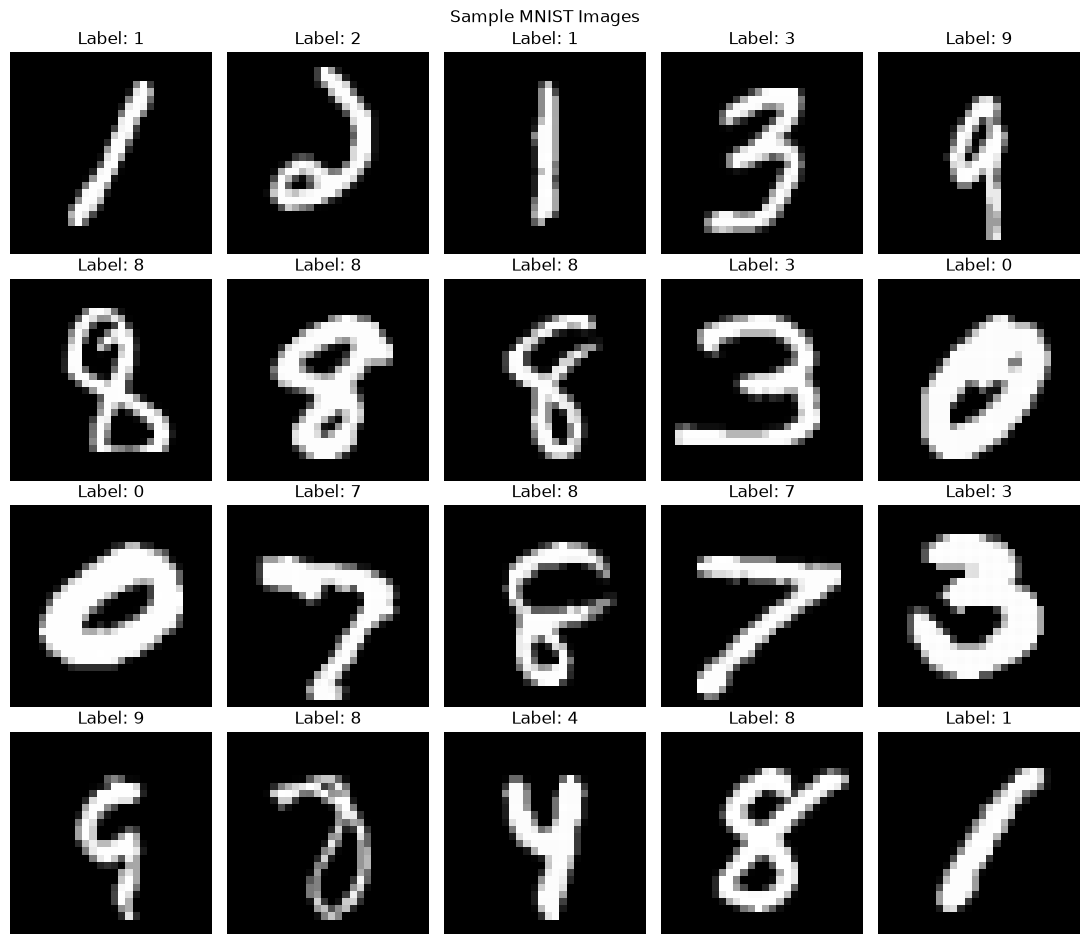

In [54]:
# Let the user preview some raw (unprocessed) sample images
offer_interactive_preview(x_train, y_train)



In [55]:
# Preprocess (normalize + add channel dim) AFTER preview so the preview
# shows the original-looking images
x_train_p = preprocess(x_train)
x_val_p = preprocess(x_val)
x_test_p = preprocess(x_test)

print("\nBuilding model...")
model = build_model()
model.summary()

print("\nTraining model...")
history = model.fit(
    x_train_p,
    y_train,
    validation_data=(x_val_p, y_val),
    epochs=10,
    batch_size=128,
    verbose=2,
)




Building model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


Training model...
Epoch 1/10
422/422 - 2s - 4ms/step - accuracy: 0.8820 - loss: 0.3935 - val_accuracy: 0.9528 - val_loss: 0.1560
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.9496 - loss: 0.1687 - val_accuracy: 0.9665 - val_loss: 0.1177
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.9627 - loss: 0.1241 - val_accuracy: 0.9675 - val_loss: 0.1081
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.9690 - loss: 0.1031 - val_accuracy: 0.9740 - val_loss: 0.0899
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.9725 - loss: 0.0878 - val_accuracy: 0.9768 - val_loss: 0.0825
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9765 - loss: 0.0765 - val_accuracy: 0.9787 - val_loss: 0.0802
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.9789 - loss: 0.0680 - val_accuracy: 0.9758 - val_loss: 0.0940
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.9807 - loss: 0.0600 - val_accuracy: 0.9780 - val_loss: 0.0815
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.9818 - loss: 0.0588 - val_accuracy: 0.9762 -


Plotting training/validation loss...
Saved loss/accuracy curves to: training_validation_loss.png


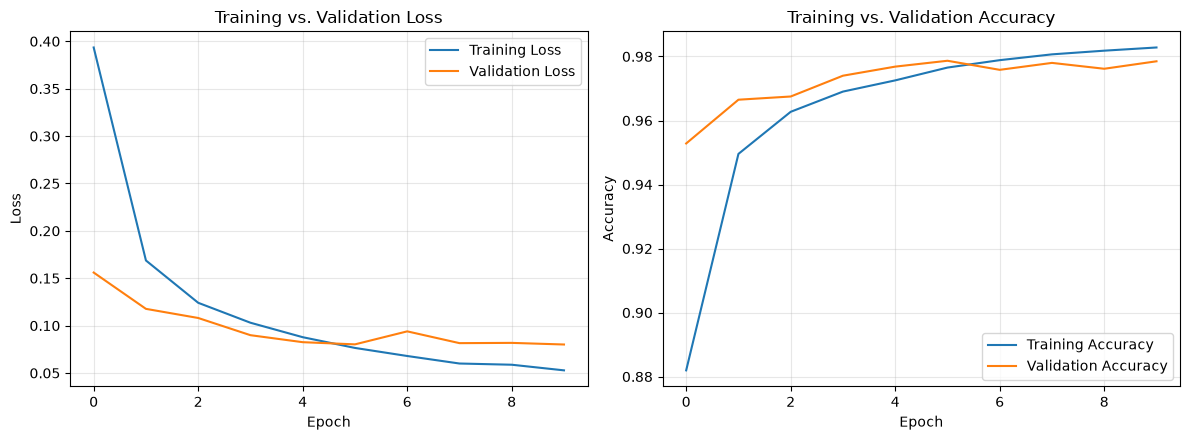


Evaluating on test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step

========== Test Set Performance ==========
Accuracy:           0.9795
Precision (macro):  0.9794
Recall (macro):     0.9794
F1-score (macro):   0.9794

Per-class report:
              precision    recall  f1-score   support

           0     0.9769    0.9908    0.9838       980
           1     0.9894    0.9912    0.9903      1135
           2     0.9834    0.9758    0.9796      1032
           3     0.9696    0.9792    0.9744      1010
           4     0.9836    0.9745    0.9790       982
           5     0.9831    0.9798    0.9815       892
           6     0.9823    0.9823    0.9823       958
           7     0.9804    0.9728    0.9766      1028
           8     0.9724    0.9784    0.9754       974
           9     0.9731    0.9693    0.9712      1009

    accuracy                         0.9795     10000
   macro avg     0.9794    0.9794    0.9794     10000
weighted avg     0.9795    0.9795    0.9795     10000



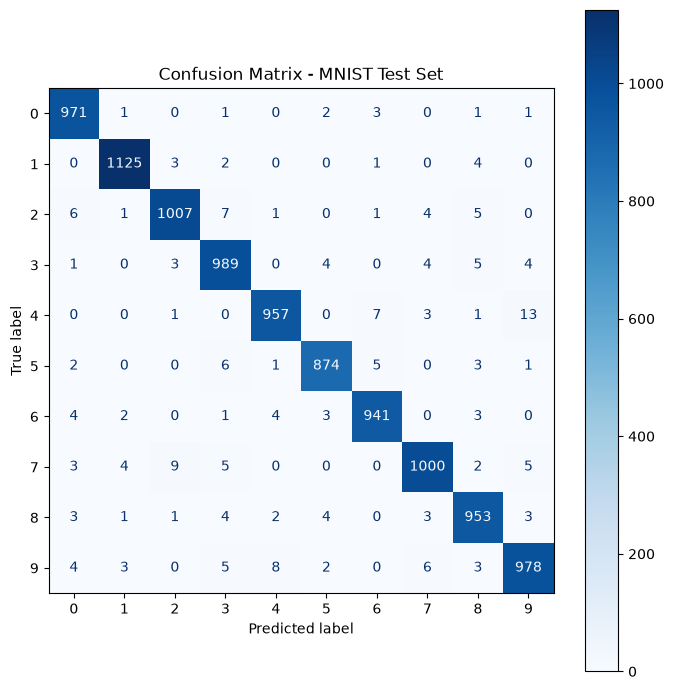

{'accuracy': 0.9795,
 'precision': 0.9794226641472659,
 'recall': 0.9794084527413268,
 'f1': 0.9794015390617223}

In [56]:

print("\nPlotting training/validation loss...")
plot_loss(history)

print("\nEvaluating on test set...")
evaluate_model(model, x_test_p, y_test)